# Updated Pipeline Assembly

> Updated Disaggregation and Aggregation

## Imports + Setup

In [128]:
## So that if you change sth in a src script you don't have to restart the kernel
%load_ext autoreload
%autoreload 2

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [129]:
## Imports
## Allowing for Imports from src folder
import sys
sys.path.append("..") # Adds the project root to the path

## Hazard + Exposure Import

In [130]:
## Getting hazard Dict
from src.data_hazard import get_haz_dict

## TODO: Enable Floods!
haz_dict = get_haz_dict()

haz_dict

{'TC': {'hazard': <climada.hazard.base.Hazard at 0x33c4093a0>,
  'impf_set': <climada.entity.impact_funcs.impact_func_set.ImpactFuncSet at 0x3458222a0>},
 'TP': {'hazard': <climada.hazard.base.Hazard at 0x35a4d31a0>,
  'impf_set': <climada.entity.impact_funcs.impact_func_set.ImpactFuncSet at 0x345823050>},
 'HL': {'hazard': <climada.hazard.base.Hazard at 0x3437c3e60>,
  'impf_set': <climada.entity.impact_funcs.impact_func_set.ImpactFuncSet at 0x33e51f350>},
 'FL': {'hazard': <climada.hazard.base.Hazard at 0x345ababa0>,
  'impf_set': <climada.entity.impact_funcs.impact_func_set.ImpactFuncSet at 0x35a401430>}}

In [132]:
from src.data_exposure import get_exposure

hazard_types = list(haz_dict.keys())

exposure_poly = get_exposure(hazard_types=hazard_types)

exposure_poly_gdf = exposure_poly.gdf

exposure_poly_gdf.head()

,DDEP_C_COD,DDEP_L_LIB,DREG_L_LIB,value,area,insurance,impf_TC,impf_TP,impf_HL,impf_FL,geometry
0,01,Ain,Auvergne-Rhône-Alpes,0.199,5762.4,0.30,1,1,1,1,"POLYGON ((6.16845 46.36746, 6.16668 46.37074, ..."
1,02,Aisne,Hauts-de-France,0.532,7361.7,0.32,1,1,1,1,"POLYGON ((4.25573 49.90398, 4.23694 49.90378, ..."
2,03,Allier,Auvergne-Rhône-Alpes,0.170,7340.1,0.30,1,1,1,1,"POLYGON ((4.00456 46.32748, 3.99436 46.32765, ..."
3,04,Alpes-de-Haute-Provence,Provence-Alpes-Côte d'Azur,0.025,6925.2,0.18,1,1,1,1,"POLYGON ((6.96709 44.62287, 6.9539 44.63783, 6..."
4,05,Hautes-Alpes,Provence-Alpes-Côte d'Azur,0.017,5548.7,0.18,1,1,1,1,"POLYGON ((7.07587 44.68512, 7.07424 44.69209, ..."


In [135]:
import climada.util.lines_polys_handler as u_lp

# TODO: Adjust Resolution
exposure_pnt = u_lp.exp_geom_to_pnt(
    exposure_poly,
    res=1000,
    to_meters=True,
    disagg_met=u_lp.DisaggMethod.FIX,
    disagg_val=None,
)

exposure_pnt_gdf = exposure_pnt.gdf

In [136]:
exposure_pnt_gdf

DDEP_C_COD  DDEP_L_LIB            DREG_L_LIB  value    area  \
0  0            01         Ain  Auvergne-Rhône-Alpes  0.199  5762.4   
   1            01         Ain  Auvergne-Rhône-Alpes  0.199  5762.4   
   2            01         Ain  Auvergne-Rhône-Alpes  0.199  5762.4   
   3            01         Ain  Auvergne-Rhône-Alpes  0.199  5762.4   
   4            01         Ain  Auvergne-Rhône-Alpes  0.199  5762.4   
...            ...         ...                   ...    ...     ...   
95 1241         95  Val-d'Oise         Île-de-France  0.381  1245.9   
   1242         95  Val-d'Oise         Île-de-France  0.381  1245.9   
   1243         95  Val-d'Oise         Île-de-France  0.381  1245.9   
   1244         95  Val-d'Oise         Île-de-France  0.381  1245.9   
   1245         95  Val-d'Oise         Île-de-France  0.381  1245.9   

         insurance  impf_TC  impf_TP  impf_HL  impf_FL  \
0  0          0.30        1        1        1        1   
   1          0.30        1        1        1        1   
   2          0.30        1        1        1        1   
   3          0.30        1        1        1        1   
   4          0.30        1        1        1        1   
...            ...      ...      ...      ...      ...   
95 1241       0.72        1        1        1        1   
   1242       0.72        1        1        1        1   
   1243       0.72        1        1        1        1   
   1244       0.72        1        1        1        1   
   1245       0.72        1        1        1        1   

                                             geometry_orig  \
0  0     POLYGON ((6.16845 46.36746, 6.16668 46.37074, ...   
   1     POLYGON ((6.16845 46.36746, 6.16668 46.37074, ...   
   2     POLYGON ((6.16845 46.36746, 6.16668 46.37074, ...   
   3     POLYGON ((6.16845 46.36746, 6.16668 46.37074, ...   
   4     POLYGON ((6.16845 46.36746, 6.16668 46.37074, ...   
...                                                    ...   
95 1241  POLYGON ((2.59447 49.04714, 2.57243 49.05926, ...   
   1242  POLYGON ((2.59447 49.04714, 2.57243 49.05926, ...   
   1243  POLYGON ((2.59447 49.04714, 2.57243 49.05926, ...   
   1244  POLYGON ((2.59447 49.04714, 2.57243 49.05926, ...   
   1245  POLYGON ((2.59447 49.04714, 2.57243 49.05926, ...   

                         geometry  
0  0     POINT (5.61991 45.62434)  
   1      POINT (5.6289 45.62434)  
   2     POINT (5.63788 45.62434)  
   3     POINT (5.61093 45.63718)  
   4     POINT (5.61991 45.63718)  
...                           ...  
95 1241  POINT (1.69863 49.22373)  
   1242  POINT (1.70761 49.22373)  
   1243  POINT (1.71659 49.22373)  
   1244  POINT (1.72558 49.22373)  
   1245  POINT (1.73456 49.22373)  

[548628 rows x 12 columns]

## Compute Impact

In [137]:
from src.helpers import comp_impact

exposure_pnt_gdf["eai"] = comp_impact(
    haz_dict=haz_dict,
    exposure_pnt_gdf=exposure_pnt_gdf
)

2026-04-24 14:57:51,447 - climada.util.coordinates - WARNING - Distance to closest centroid is greater than 0.000237 degree for 548477 coordinates.
2026-04-24 15:05:10,392 - climada.util.coordinates - WARNING - Distance to closest centroid is greater than 0.004492 degree for 14285 coordinates.


In [138]:
from src.helpers import comp_insurance

exposure_pnt_gdf["insurance"] = comp_insurance(
    method="eai",
    scaling_factor=0.5,
    insurance_current=exposure_pnt_gdf["insurance"],
    eai=exposure_pnt_gdf["eai"]
)

In [139]:

exposure_pnt_gdf

DDEP_C_COD  DDEP_L_LIB            DREG_L_LIB  value    area  \
0  0            01         Ain  Auvergne-Rhône-Alpes  0.199  5762.4   
   1            01         Ain  Auvergne-Rhône-Alpes  0.199  5762.4   
   2            01         Ain  Auvergne-Rhône-Alpes  0.199  5762.4   
   3            01         Ain  Auvergne-Rhône-Alpes  0.199  5762.4   
   4            01         Ain  Auvergne-Rhône-Alpes  0.199  5762.4   
...            ...         ...                   ...    ...     ...   
95 1241         95  Val-d'Oise         Île-de-France  0.381  1245.9   
   1242         95  Val-d'Oise         Île-de-France  0.381  1245.9   
   1243         95  Val-d'Oise         Île-de-France  0.381  1245.9   
   1244         95  Val-d'Oise         Île-de-France  0.381  1245.9   
   1245         95  Val-d'Oise         Île-de-France  0.381  1245.9   

         insurance  impf_TC  impf_TP  impf_HL  impf_FL  \
0  0      0.302261        1        1        1        1   
   1      0.300000        1        1        1        1   
   2      0.300000        1        1        1        1   
   3      0.305116        1        1        1        1   
   4      0.305116        1        1        1        1   
...            ...      ...      ...      ...      ...   
95 1241   0.722714        1        1        1        1   
   1242   0.722714        1        1        1        1   
   1243   0.722714        1        1        1        1   
   1244   0.722714        1        1        1        1   
   1245   0.722714        1        1        1        1   

                                             geometry_orig  \
0  0     POLYGON ((6.16845 46.36746, 6.16668 46.37074, ...   
   1     POLYGON ((6.16845 46.36746, 6.16668 46.37074, ...   
   2     POLYGON ((6.16845 46.36746, 6.16668 46.37074, ...   
   3     POLYGON ((6.16845 46.36746, 6.16668 46.37074, ...   
   4     POLYGON ((6.16845 46.36746, 6.16668 46.37074, ...   
...                                                    ...   
95 1241  POLYGON ((2.59447 49.04714, 2.57243 49.05926, ...   
   1242  POLYGON ((2.59447 49.04714, 2.57243 49.05926, ...   
   1243  POLYGON ((2.59447 49.04714, 2.57243 49.05926, ...   
   1244  POLYGON ((2.59447 49.04714, 2.57243 49.05926, ...   
   1245  POLYGON ((2.59447 49.04714, 2.57243 49.05926, ...   

                         geometry       eai  
0  0     POINT (5.61991 45.62434)  0.004521  
   1      POINT (5.6289 45.62434)  0.000000  
   2     POINT (5.63788 45.62434)  0.000000  
   3     POINT (5.61093 45.63718)  0.010231  
   4     POINT (5.61991 45.63718)  0.010231  
...                           ...       ...  
95 1241  POINT (1.69863 49.22373)  0.005427  
   1242  POINT (1.70761 49.22373)  0.005427  
   1243  POINT (1.71659 49.22373)  0.005427  
   1244  POINT (1.72558 49.22373)  0.005427  
   1245  POINT (1.73456 49.22373)  0.005427  

[548628 rows x 13 columns]

In [140]:
comp_who_pays(
        relative_damage=exposure_pnt_gdf["eai"],
        insured=exposure_pnt_gdf["insurance"]
).max()


F    1.000000
I    0.964564
G    0.839500
dtype: float64

In [141]:
from src.helpers import comp_who_pays

result = comp_who_pays(
    relative_damage=exposure_pnt_gdf["eai"],
    insured=exposure_pnt_gdf["insurance"]
)

exposure_pnt_gdf[["F", "I", "G"]] = result[["F", "I", "G"]].to_numpy()

In [142]:
## Computing Relative Payments
result = (exposure_pnt_gdf[['F', 'I', 'G']]
          .mul(exposure_pnt_gdf['eai'], axis=0)
          .mul(exposure_pnt_gdf["value"], axis=0)
          )

exposure_pnt_gdf = exposure_pnt_gdf.join(result.add_suffix('_relative'))

In [116]:
exposure_pnt_gdf

DDEP_C_COD  DDEP_L_LIB            DREG_L_LIB  value    area  insurance  \
0  0          01         Ain  Auvergne-Rhône-Alpes  0.199  5762.4   0.300000   
   1          01         Ain  Auvergne-Rhône-Alpes  0.199  5762.4   0.300000   
   2          01         Ain  Auvergne-Rhône-Alpes  0.199  5762.4   0.305419   
   3          01         Ain  Auvergne-Rhône-Alpes  0.199  5762.4   0.300000   
   4          01         Ain  Auvergne-Rhône-Alpes  0.199  5762.4   0.300000   
...          ...         ...                   ...    ...     ...        ...   
95 54         95  Val-d'Oise         Île-de-France  0.381  1245.9   0.722159   
   55         95  Val-d'Oise         Île-de-France  0.381  1245.9   0.722221   
   56         95  Val-d'Oise         Île-de-France  0.381  1245.9   0.722221   
   57         95  Val-d'Oise         Île-de-France  0.381  1245.9   0.722221   
   58         95  Val-d'Oise         Île-de-France  0.381  1245.9   0.722875   

       impf_TC  impf_TP  impf_HL  \
0  0         1        1        1   
   1         1        1        1   
   2         1        1        1   
   3         1        1        1   
   4         1        1        1   
...        ...      ...      ...   
95 54        1        1        1   
   55        1        1        1   
   56        1        1        1   
   57        1        1        1   
   58        1        1        1   

                                           geometry_orig  \
0  0   POLYGON ((6.16845 46.36746, 6.16668 46.37074, ...   
   1   POLYGON ((6.16845 46.36746, 6.16668 46.37074, ...   
   2   POLYGON ((6.16845 46.36746, 6.16668 46.37074, ...   
   3   POLYGON ((6.16845 46.36746, 6.16668 46.37074, ...   
   4   POLYGON ((6.16845 46.36746, 6.16668 46.37074, ...   
...                                                  ...   
95 54  POLYGON ((2.59447 49.04714, 2.57243 49.05926, ...   
   55  POLYGON ((2.59447 49.04714, 2.57243 49.05926, ...   
   56  POLYGON ((2.59447 49.04714, 2.57243 49.05926, ...   
   57  POLYGON ((2.59447 49.04714, 2.57243 49.05926, ...   
   58  POLYGON ((2.59447 49.04714, 2.57243 49.05926, ...   

                       geometry       eai    F    I    G  F_relative  \
0  0   POINT (5.63058 45.66149)  0.000000  1.0  0.0  0.0    0.000000   
   1   POINT (5.68058 45.66149)  0.000000  1.0  0.0  0.0    0.000000   
   2   POINT (5.58058 45.71149)  0.010231  1.0  0.0  0.0    0.002036   
   3   POINT (5.63058 45.71149)  0.000000  1.0  0.0  0.0    0.000000   
   4   POINT (5.68058 45.71149)  0.000000  1.0  0.0  0.0    0.000000   
...                         ...       ...  ...  ...  ...         ...   
95 54   POINT (2.1088 49.15868)  0.004077  1.0  0.0  0.0    0.001553   
   55   POINT (2.1588 49.15868)  0.004194  1.0  0.0  0.0    0.001598   
   56   POINT (2.2088 49.15868)  0.004194  1.0  0.0  0.0    0.001598   
   57   POINT (2.3088 49.15868)  0.004194  1.0  0.0  0.0    0.001598   
   58   POINT (1.7088 49.20868)  0.005427  1.0  0.0  0.0    0.002068   

       I_relative  G_relative  
0  0          0.0         0.0  
   1          0.0         0.0  
   2          0.0         0.0  
   3          0.0         0.0  
   4          0.0         0.0  
...           ...         ...  
95 54         0.0         0.0  
   55         0.0         0.0  
   56         0.0         0.0  
   57         0.0         0.0  
   58         0.0         0.0  

[25740 rows x 18 columns]

In [143]:
from src.helpers import agg_to_departement

## TODO: Rename results to sth else
results = agg_to_departement(
    pnt_gdf=exposure_pnt_gdf,
    value_cols=["value", "insurance", "eai", "F", "I", "G", "F_relative", "I_relative", "G_relative"],
    agg_func="mean"
)

results

,DDEP_C_COD,DDEP_L_LIB,DREG_L_LIB,area,value,insurance,eai,F,I,G,F_relative,I_relative,G_relative,geometry_orig
0,01,Ain,Auvergne-Rhône-Alpes,5762.4,0.199,0.309102,0.018204,1.000000,0.000000,0.000000,0.003623,0.000000e+00,0.000000,"POLYGON ((6.16845 46.36746, 6.16668 46.37074, ..."
1,02,Aisne,Hauts-de-France,7361.7,0.532,0.322433,0.004867,0.999849,0.000151,0.000000,0.002551,3.817739e-05,0.000000,"POLYGON ((4.25573 49.90398, 4.23694 49.90378, ..."
2,03,Allier,Auvergne-Rhône-Alpes,7340.1,0.170,0.315211,0.030421,0.999779,0.000019,0.000202,0.005140,2.774836e-06,0.000029,"POLYGON ((4.00456 46.32748, 3.99436 46.32765, ..."
3,04,Alpes-de-Haute-Provence,Provence-Alpes-Côte d'Azur,6925.2,0.025,0.180290,0.000580,0.999670,0.000028,0.000303,0.000007,6.530073e-07,0.000007,"POLYGON ((6.96709 44.62287, 6.9539 44.63783, 6..."
4,05,Hautes-Alpes,Provence-Alpes-Côte d'Azur,5548.7,0.017,0.180260,0.000519,0.999610,0.000032,0.000358,0.000003,4.558100e-07,0.000005,"POLYGON ((7.07587 44.68512, 7.07424 44.69209, ..."
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
91,91,Essonne,Île-de-France,1804.4,0.403,0.728453,0.016906,1.000000,0.000000,0.000000,0.006813,0.000000e+00,0.000000,"POLYGON ((2.58407 48.67715, 2.58038 48.68948, ..."
92,92,Hauts-de-Seine,Île-de-France,175.6,NaN,0.724370,0.008741,1.000000,0.000000,0.000000,NaN,NaN,NaN,"POLYGON ((2.33598 48.93158, 2.33491 48.94154, ..."
93,93,Seine-Saint-Denis,Île-de-France,236.2,NaN,0.724608,0.009215,1.000000,0.000000,0.000000,NaN,NaN,NaN,"POLYGON ((2.6026 48.92936, 2.6024 48.93532, 2...."
94,94,Val-de-Marne,Île-de-France,245.0,0.029,0.726617,0.013234,1.000000,0.000000,0.000000,0.000384,0.000000e+00,0.000000,"POLYGON ((2.61482 48.76112, 2.60645 48.77333, ..."


In [144]:
from src.helpers import comp_damage_map

results["damaged_area"] = comp_damage_map(
    eai=results["eai"],
    value=results["value"],
    area=results["area"]
)

## Computing Relative Payments

result = results[['F', 'I', 'G']].mul(results['damaged_area'], axis=0)

results = results.join(result.add_suffix('_area'))

results

,DDEP_C_COD,DDEP_L_LIB,DREG_L_LIB,area,value,insurance,eai,F,I,G,F_relative,I_relative,G_relative,geometry_orig,damaged_area,F_area,I_area,G_area
0,01,Ain,Auvergne-Rhône-Alpes,5762.4,0.199,0.309102,0.018204,1.000000,0.000000,0.000000,0.003623,0.000000e+00,0.000000,"POLYGON ((6.16845 46.36746, 6.16668 46.37074, ...",20.875157,20.875157,0.000000,0.000000
1,02,Aisne,Hauts-de-France,7361.7,0.532,0.322433,0.004867,0.999849,0.000151,0.000000,0.002551,3.817739e-05,0.000000,"POLYGON ((4.25573 49.90398, 4.23694 49.90378, ...",19.059587,19.056717,0.002870,0.000000
2,03,Allier,Auvergne-Rhône-Alpes,7340.1,0.170,0.315211,0.030421,0.999779,0.000019,0.000202,0.005140,2.774836e-06,0.000029,"POLYGON ((4.00456 46.32748, 3.99436 46.32765, ...",37.960457,37.952052,0.000739,0.007666
3,04,Alpes-de-Haute-Provence,Provence-Alpes-Côte d'Azur,6925.2,0.025,0.180290,0.000580,0.999670,0.000028,0.000303,0.000007,6.530073e-07,0.000007,"POLYGON ((6.96709 44.62287, 6.9539 44.63783, 6...",0.100414,0.100380,0.000003,0.000030
4,05,Hautes-Alpes,Provence-Alpes-Côte d'Azur,5548.7,0.017,0.180260,0.000519,0.999610,0.000032,0.000358,0.000003,4.558100e-07,0.000005,"POLYGON ((7.07587 44.68512, 7.07424 44.69209, ...",0.048982,0.048963,0.000002,0.000018
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
91,91,Essonne,Île-de-France,1804.4,0.403,0.728453,0.016906,1.000000,0.000000,0.000000,0.006813,0.000000e+00,0.000000,"POLYGON ((2.58407 48.67715, 2.58038 48.68948, ...",12.293304,12.293304,0.000000,0.000000
92,92,Hauts-de-Seine,Île-de-France,175.6,NaN,0.724370,0.008741,1.000000,0.000000,0.000000,NaN,NaN,NaN,"POLYGON ((2.33598 48.93158, 2.33491 48.94154, ...",NaN,NaN,NaN,NaN
93,93,Seine-Saint-Denis,Île-de-France,236.2,NaN,0.724608,0.009215,1.000000,0.000000,0.000000,NaN,NaN,NaN,"POLYGON ((2.6026 48.92936, 2.6024 48.93532, 2....",NaN,NaN,NaN,NaN
94,94,Val-de-Marne,Île-de-France,245.0,0.029,0.726617,0.013234,1.000000,0.000000,0.000000,0.000384,0.000000e+00,0.000000,"POLYGON ((2.61482 48.76112, 2.60645 48.77333, ...",0.094031,0.094031,0.000000,0.000000


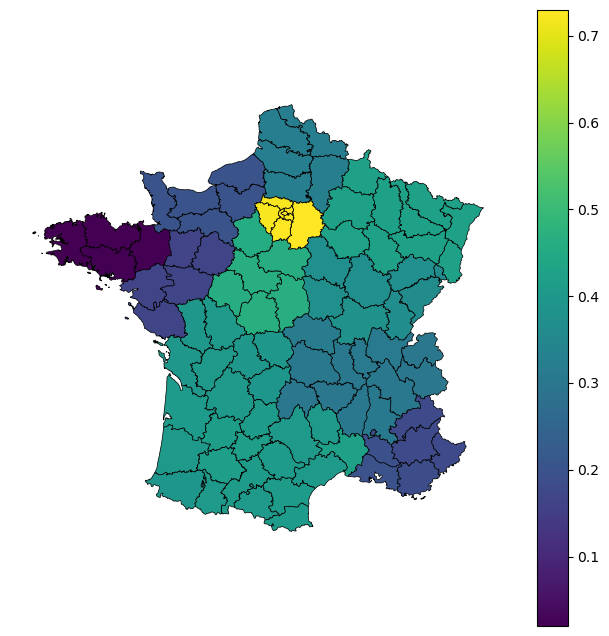

In [160]:
## Plotting Any Column
## Idea: Value (Exposure) x EAI = damaged_area

import geopandas as gpd
import matplotlib.pyplot as plt

# gdf is your GeoDataFrame
# columns: geometry (polygons), value (numeric or categorical)

fig, ax = plt.subplots(figsize=(8, 8))

results.plot(
    column="insurance",      # column used for coloring
    ax=ax,
    cmap="viridis",      # color map
    legend=True,         # show color bar / legend
    edgecolor="black",   # polygon borders
    linewidth=0.5
)

ax.set_axis_off()
plt.show()

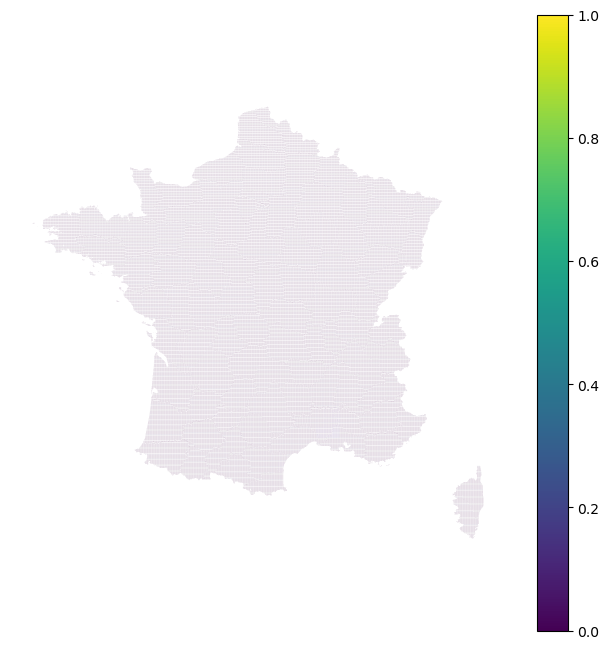

In [164]:
fig, ax = plt.subplots(figsize=(8, 8))

exposure_pnt_gdf.plot(
    column="eai",        # column used for coloring
    ax=ax,
    cmap="viridis",
    legend=True,
    marker=".",        # circle marker (optional)
    markersize=0.05,     # IMPORTANT for points
    edgecolor="black",
    linewidth=0
)

ax.set_axis_off()
plt.show()

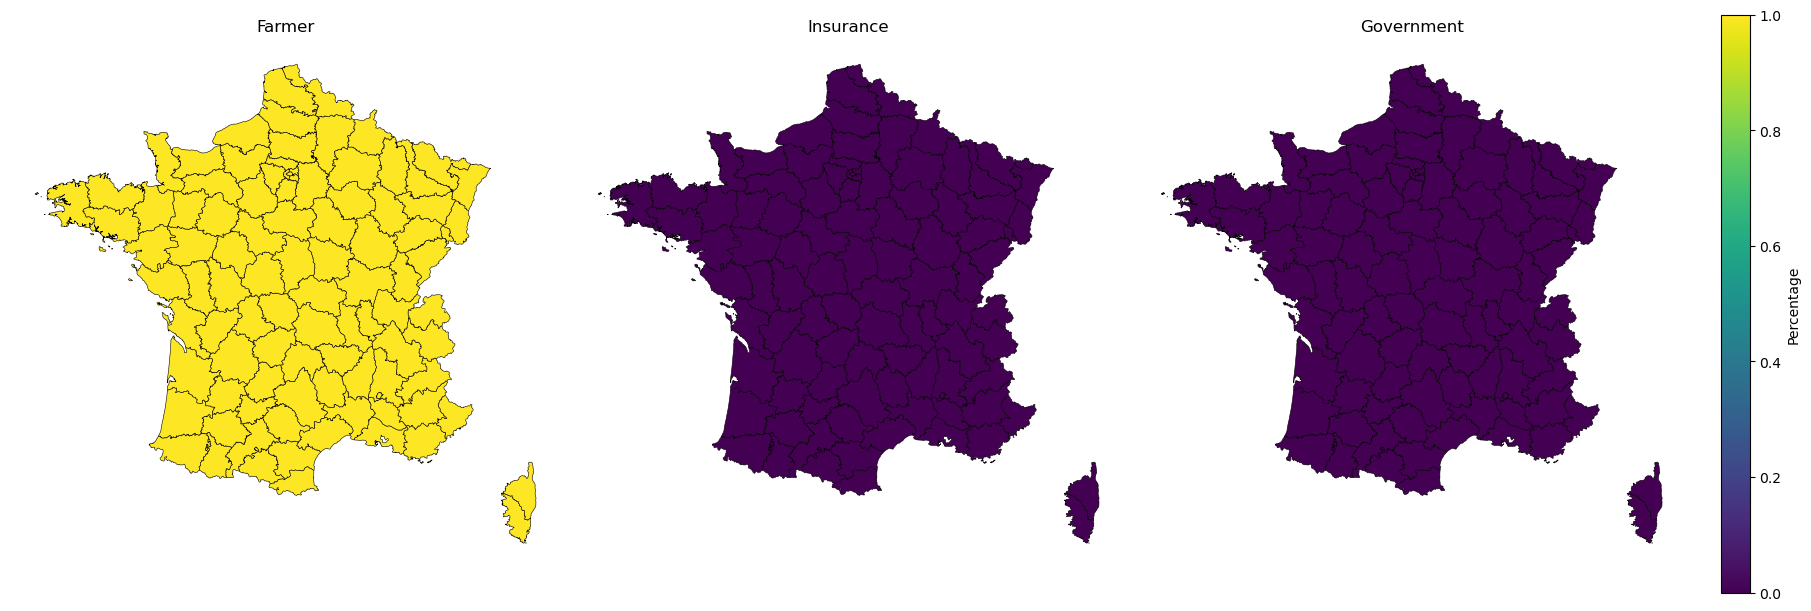

In [148]:
## Plotting
## Who Pays Damaged Area in Percent

import geopandas as gpd
import matplotlib.pyplot as plt
import matplotlib as mpl

# Columns to plot
cols = ["F", "I", "G"]
titles = ["Farmer", "Insurance", "Government"]

# Create figure and axes
fig, axes = plt.subplots(
    nrows=1,
    ncols=3,
    figsize=(18, 6),
    constrained_layout=True
)

# Shared color normalization (0–1 for percentages)
# Compute global min/max across all three columns
#vmin = df[cols].min().min()
#vmax = df[cols].max().max()
# norm = mpl.colors.Normalize(vmin=vmin, vmax=vmax)

# For Percentages
norm = mpl.colors.Normalize(vmin=0, vmax=1)

cmap = "viridis"

# Plot each column
for ax, col, title in zip(axes, cols, titles):
    results.plot(
        column=col,
        ax=ax,
        cmap=cmap,
        norm=norm,              # ensures shared scale
        edgecolor="black",
        linewidth=0.4
    )
    ax.set_title(title)
    ax.set_axis_off()

# Create a single colorbar
sm = mpl.cm.ScalarMappable(
    cmap=cmap,
    norm=norm
)
sm.set_array([])  # required for older matplotlib versions

cbar = fig.colorbar(
    sm,
    ax=axes,
    orientation="vertical",
    fraction=0.025,
    pad=0.02
)
cbar.set_label("Percentage")

plt.show()

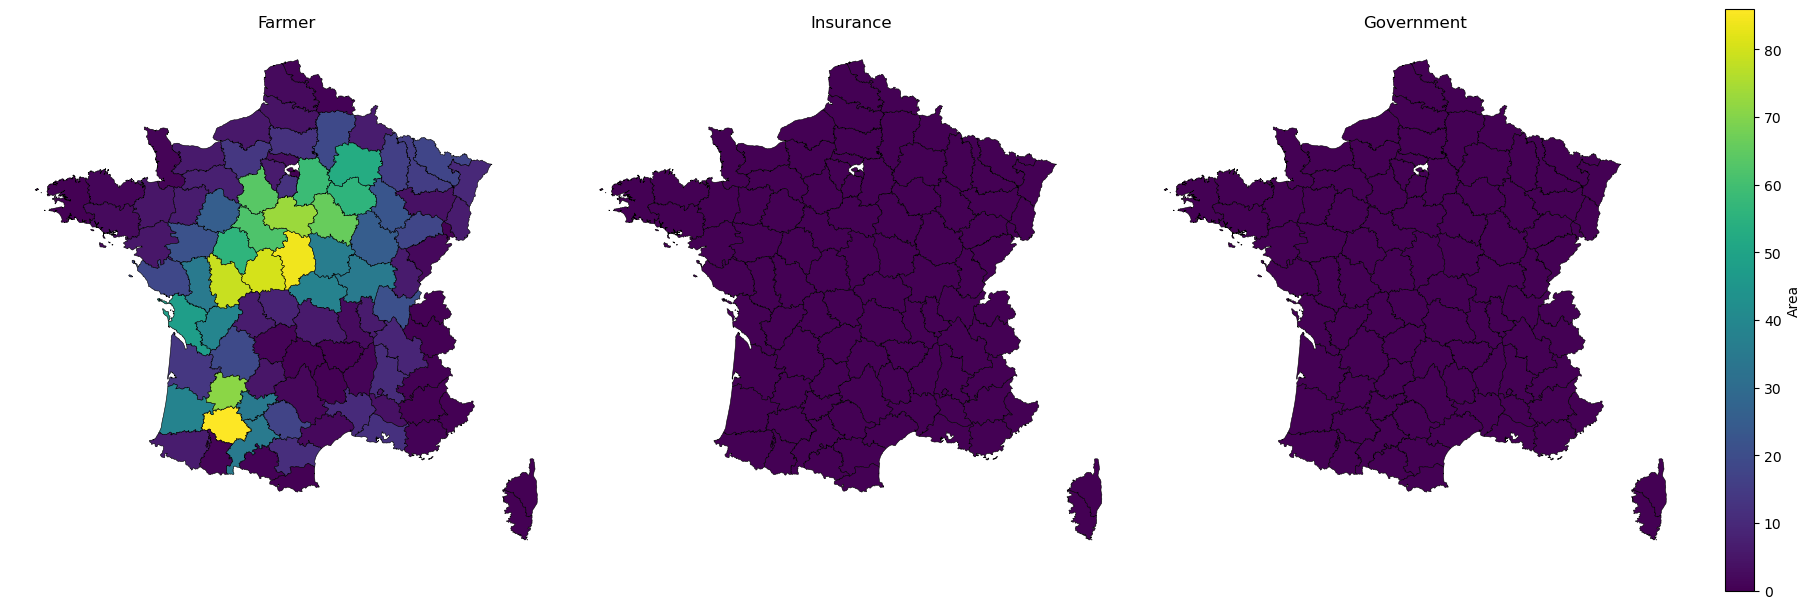

In [149]:
## Plotting
## Who Pays Damaged Area per Deparetement
## Percentage Payed x Damaged Area

import geopandas as gpd
import matplotlib.pyplot as plt
import matplotlib as mpl

# Columns to plot
cols = ["F_area", "I_area", "G_area"]
titles = ["Farmer", "Insurance", "Government"]

# Create figure and axes
fig, axes = plt.subplots(
    nrows=1,
    ncols=3,
    figsize=(18, 6),
    constrained_layout=True
)

# Shared color normalization (0–1 for percentages)
# Compute global min/max across all three columns
vmin = results[cols].min().min()
vmax = results[cols].max().max()
norm = mpl.colors.Normalize(vmin=vmin, vmax=vmax)

# For Percentages
# norm = mpl.colors.Normalize(vmin=0, vmax=1)

cmap = "viridis"

# Plot each column
for ax, col, title in zip(axes, cols, titles):
    results.plot(
        column=col,
        ax=ax,
        cmap=cmap,
        norm=norm,              # ensures shared scale
        edgecolor="black",
        linewidth=0.4
    )
    ax.set_title(title)
    ax.set_axis_off()

# Create a single colorbar
sm = mpl.cm.ScalarMappable(
    cmap=cmap,
    norm=norm
)
sm.set_array([])  # required for older matplotlib versions

cbar = fig.colorbar(
    sm,
    ax=axes,
    orientation="vertical",
    fraction=0.025,
    pad=0.02
)
cbar.set_label("Area")

plt.show()

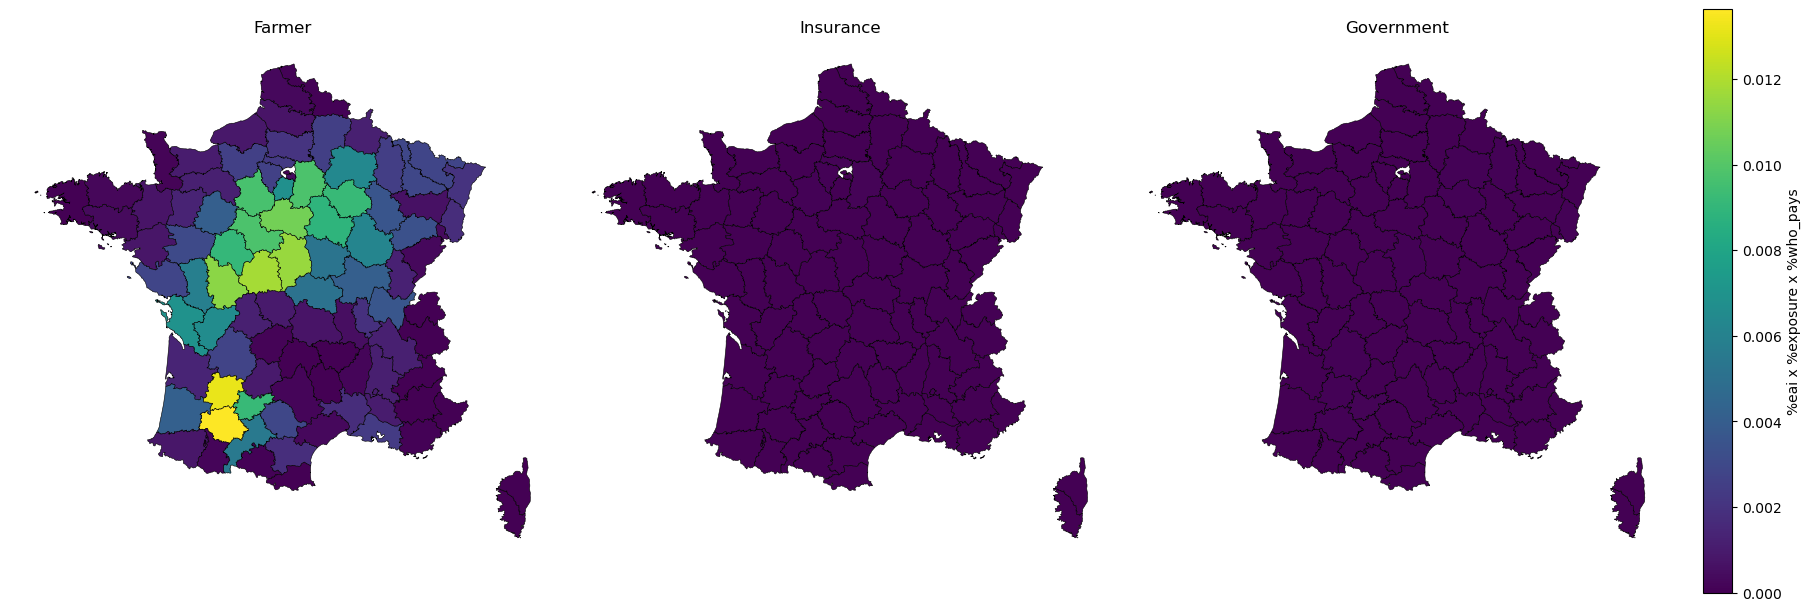

In [150]:
## Plotting
## Who Pays Damaged Area per Deparetement
## Percentage Payed x Damaged Area

import geopandas as gpd
import matplotlib.pyplot as plt
import matplotlib as mpl

# Columns to plot
cols = ["F_relative", "I_relative", "G_relative"]
titles = ["Farmer", "Insurance", "Government"]

# Create figure and axes
fig, axes = plt.subplots(
    nrows=1,
    ncols=3,
    figsize=(18, 6),
    constrained_layout=True
)

# Shared color normalization (0–1 for percentages)
# Compute global min/max across all three columns
vmin = results[cols].min().min()
vmax = results[cols].max().max()
norm = mpl.colors.Normalize(vmin=vmin, vmax=vmax)

# For Percentages
# norm = mpl.colors.Normalize(vmin=0, vmax=1)

cmap = "viridis"

# Plot each column
for ax, col, title in zip(axes, cols, titles):
    results.plot(
        column=col,
        ax=ax,
        cmap=cmap,
        norm=norm,              # ensures shared scale
        edgecolor="black",
        linewidth=0.4
    )
    ax.set_title(title)
    ax.set_axis_off()

# Create a single colorbar
sm = mpl.cm.ScalarMappable(
    cmap=cmap,
    norm=norm
)
sm.set_array([])  # required for older matplotlib versions

cbar = fig.colorbar(
    sm,
    ax=axes,
    orientation="vertical",
    fraction=0.025,
    pad=0.02
)
cbar.set_label("%eai x %exposure x %who_pays")

plt.show()

# TODOs
- Make Nicely Structured Pipeline
- Szenario Function
- Plotting and Results